# Exploratory Data Analysis and Statistical Analysis Notebook

This notebook imports the cleaned and feature enriched datasets from the Data_Cleaning_and_Feature_Engineering.ipyb notebook and performs exploratory data analysis, Hypothesis Testing and Regression Modeling. The objective of the analysis is to find answer to the following business question -

###               "What factors influence a movie’s financial performance and audience reception?"

### Importing all necessary libararies and packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

### Importing the cleaned and feature enriched datasets from earlier notebook

In [4]:
movie_df = pd.read_csv('final_dataset.csv')
financial_df = pd.read_csv('financial_dataset.csv')

## Explolatory Data Analysis

### Genre Performance: Revenue and Audience Reception

The following visualizations compare movie genres based on two key success metrics:

- Median Box Office Revenue (in millions)
- Average Weighted Audience Rating

These analyses provide an initial understanding of which genres tend to perform strongly commercially and which genres receive higher audience appreciation.

In [5]:
financial_df['primary_genre'].nunique() # Checking unique genres in dataset

20

In [6]:
#Filtering the data to include movies with more than 500 reviews to improve reliability of data
filtered_df = financial_df[financial_df['review_count'] >= 500]
filtered_df['primary_genre'].nunique()

18

In [7]:
# Creating a dataset with performance metrics of each genre
genre_df = filtered_df.groupby('primary_genre').agg(genre_avg_revenue = ('revenue','mean'),
                                                     genre_weighted_rating = ('weighted_rating','mean'),
                                                     genre_movie_count = ('movieId','count'),
                                                     genre_median_revenue =('revenue','median'))

In [8]:
# Adding Formatted columns to improve readability of visualizations
genre_df['genre_avg_revenue_mn'] = (genre_df['genre_avg_revenue']/1000000).round(1)
genre_df['genre_median_revenue_mn'] = (genre_df['genre_median_revenue']/1000000).round(1)
genre_df['genre_weighted_rating'] = genre_df['genre_weighted_rating'].round(2)
genre_df

,genre_avg_revenue,genre_weighted_rating,genre_movie_count,genre_median_revenue,genre_avg_revenue_mn,genre_median_revenue_mn
primary_genre,,,,,,
Action,1.728918e+08,3.31,596,83778887.0,172.9,83.8
Adventure,2.502215e+08,3.38,306,146811809.0,250.2,146.8
Animation,3.100471e+08,3.46,97,245724603.0,310.0,245.7
Comedy,8.858052e+07,3.36,625,49797148.0,88.6,49.8
Crime,6.825395e+07,3.57,170,39052416.5,68.3,39.1
Documentary,1.941835e+07,3.65,21,6706368.0,19.4,6.7
Drama,8.160298e+07,3.57,718,40972016.0,81.6,41.0
Family,3.354433e+08,3.33,35,169956806.0,335.4,170.0
Fantasy,1.566942e+08,3.37,105,90383208.0,156.7,90.4


In [9]:
# Sorting by median revenue to compare financial performance of Genres
genre_rev_df = genre_df.sort_values(by='genre_median_revenue_mn',ascending = False)

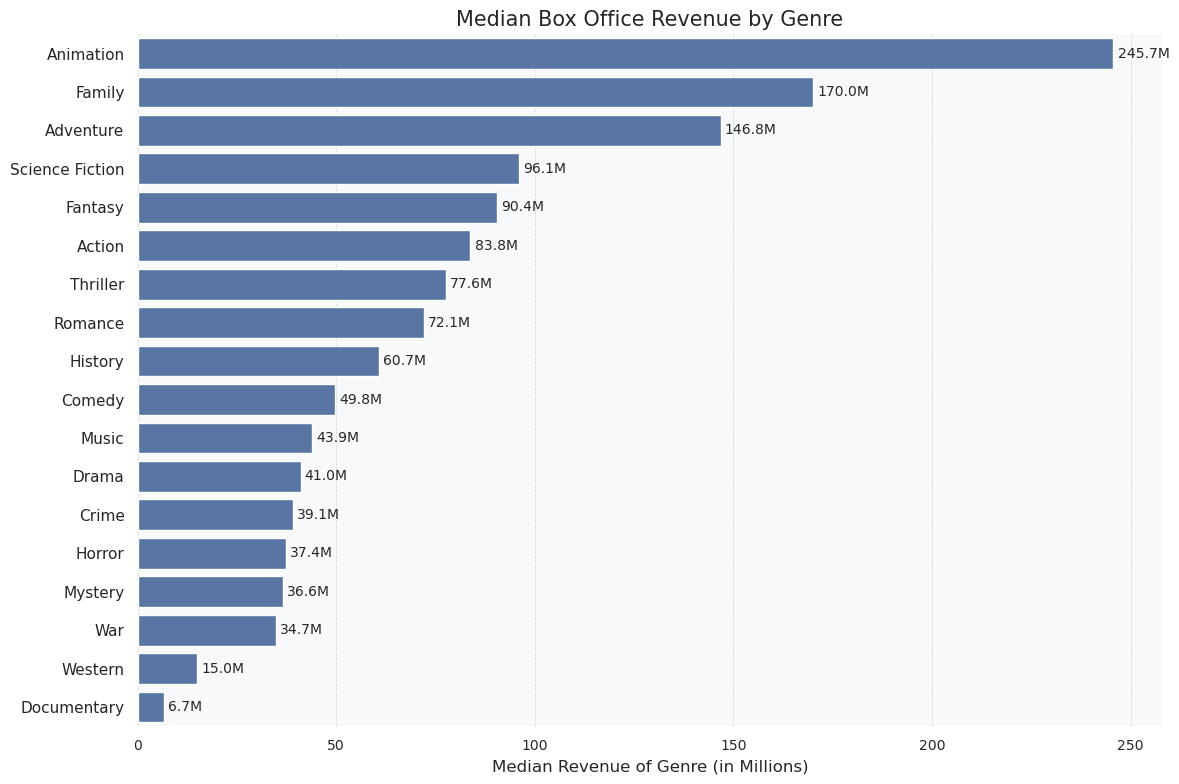

In [10]:
plt.figure(figsize =(12,8))
sns.set_theme(
    style='whitegrid',
    font='sans-serif',
    rc={
        'axes.facecolor': '#f8f9fa',   # softer background
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d9',       # lighter gridlines
        'grid.linestyle': '--',
        'grid.linewidth': 0.6,
        'axes.edgecolor': '#cccccc',
        'axes.labelsize': 12,
        'axes.titlesize': 15,
        'xtick.labelsize': 10,
        'ytick.labelsize': 11
    }
)
ax = sns.barplot(y=genre_rev_df.index,x='genre_median_revenue_mn',data=genre_rev_df)
ax.set_ylabel(None)
ax.set_xlabel('Median Revenue of Genre (in Millions)')
ax.set_title('Median Box Office Revenue by Genre')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1fM', padding=3,fontsize =10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [11]:
# Sorting by weighted rating to compare audience reception of Genres
genre_rating_df = genre_df.sort_values(by='genre_weighted_rating',ascending = False)

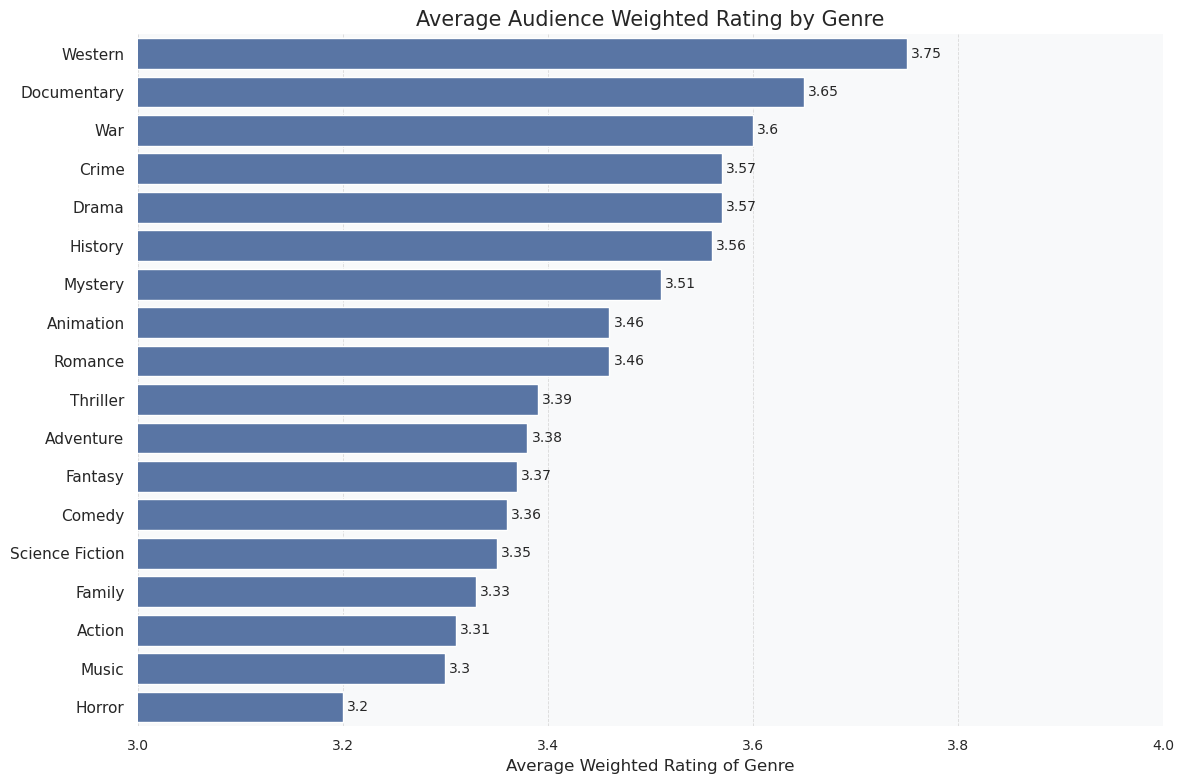

In [12]:
plt.figure(figsize =(12,8))
ax = sns.barplot(y=genre_rating_df.index,x='genre_weighted_rating',data=genre_rating_df)
ax.set_xlabel('Average Weighted Rating of Genre')
ax.set_xlim(3,4)
ax.set_ylabel(None)
ax.set_title('Average Audience Weighted Rating by Genre')
for container in ax.containers:
    ax.bar_label(container, padding=3,fontsize =10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Key Insights

Genres such as *Western*, *Documentary*, and *War* show the highest audience ratings, but comparatively low median box office revenues, suggesting that critically appreciated movies are not always commercially successful.

In contrast, *Animation*, *Family*, and *Adventure* are the strongest performing genres financially, with the highest median revenues despite relatively moderate audience ratings.

Genres like *Romance* and *Thriller* demonstrate balanced performance across both audience reception and commercial success.

> Note: Genres such as *War*, *History*, and *Western* contain relatively small sample sizes compared to larger genres like *Drama* and *Comedy*, so their results should be interpreted with caution.

### Relationship Between Movie Budget and Box office Revenue

This analysis examines the relationship between movie production budgets and box office revenue to determine whether higher-budget movies tend to achieve stronger financial performance

In [13]:
financial_df[['budget','revenue']].describe() # Inspecting the budget and revenue column stats

,budget,revenue
count,5.365000e+03,5.365000e+03
mean,3.117957e+07,9.055298e+07
std,4.019199e+07,1.663267e+08
min,1.000000e+00,1.000000e+00
25%,5.300000e+06,7.100000e+06
50%,1.700000e+07,3.000000e+07
75%,4.000000e+07,1.000000e+08
max,3.800000e+08,2.787965e+09


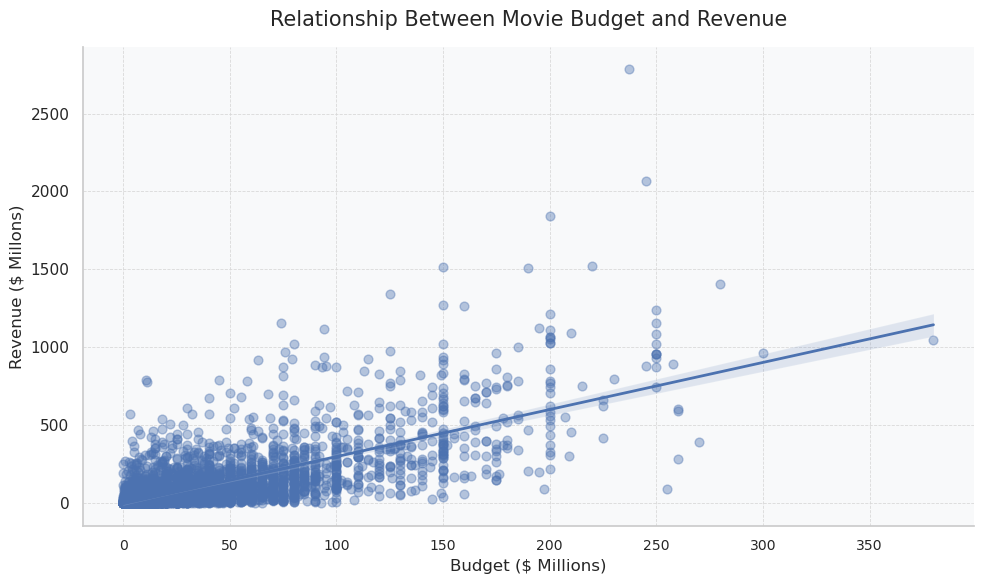

In [14]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10,6))

# Scatterplot with transparency and smaller markers
ax = sns.regplot(
    x='budget',
    y='revenue',
    data=financial_df,
    scatter_kws={
        'alpha': 0.4,   # transparency
        's': 40         # smaller marker size
    },
    line_kws={
        'linewidth': 2  # regression line thickness
    }
)

# Format axes in millions
million_formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.0f}')

ax.xaxis.set_major_formatter(million_formatter)
ax.yaxis.set_major_formatter(million_formatter)

# Labels and title
ax.set_xlabel('Budget ($ Millions)')
ax.set_ylabel('Revenue ($ Millons)')
ax.set_title('Relationship Between Movie Budget and Revenue', pad=15)
# Cleaner appearance
sns.despine()

plt.tight_layout()
plt.show()

In [15]:
# Getting Pearson correlation co-efficient between budget and revenue
financial_df['budget'].corr(financial_df['revenue']) 

0.7300828288616641

### Key Insights

The scatterplot shows a clear positive relationship between movie budget and box office revenue, with a correlation coefficient of **0.73**, indicating a moderately strong linear association.

Most movies follow an approximate upward trend, although some notable **outliers** exist, including high-budget underperformers and exceptionally successful blockbusters.

The observed relationship suggests that budget is an important factor influencing box office revenue and is suitable for further **regression analysis**.

### Top 5 Directors by Revenue and Audience Reception

This analysis identifies the top-performing directors based on both average box office revenue and average weighted audience ratings across their movies.

To improve the reliability of the results, only movies with a minimum review count of 500 were included in the analysis. Additionally, only directors with at least 10 movies in the filtered dataset were considered.

In [16]:
# Ranking the filtered directors by average revenue generated
director_df = filtered_df.groupby('director').agg(movie_count = ('movieId','count'),
                                    mean_revenue = ('revenue','mean'),
                                    avg_weighted_rating =('weighted_rating','mean')).\
                                sort_values(by=['mean_revenue','avg_weighted_rating'],ascending =[False,False])

# Creating a rating cutoff to only select directors in TOP 25 percentile of audience ratings
rating_cutoff = director_df['avg_weighted_rating'].quantile(0.75)
# Filtering directors with more than 10 movies and ratings higher than rating cutoff
filtered_dir_df = director_df[(director_df['movie_count'] >=10) & (director_df['avg_weighted_rating'] >=rating_cutoff)].head()
filtered_dir_df['mean_revenue_mn'] = (filtered_dir_df['mean_revenue']/1000000).round(2)
filtered_dir_df['avg_weighted_rating'] = filtered_dir_df['avg_weighted_rating'].round(2)
filtered_dir_df

,movie_count,mean_revenue,avg_weighted_rating,mean_revenue_mn
director,,,,
Peter Jackson,11,5.934768e+08,3.69,593.48
Steven Spielberg,28,3.235884e+08,3.61,323.59
David Fincher,10,2.139346e+08,3.72,213.93
Martin Scorsese,17,1.157014e+08,3.76,115.70
Francis Ford Coppola,11,8.587867e+07,3.68,85.88


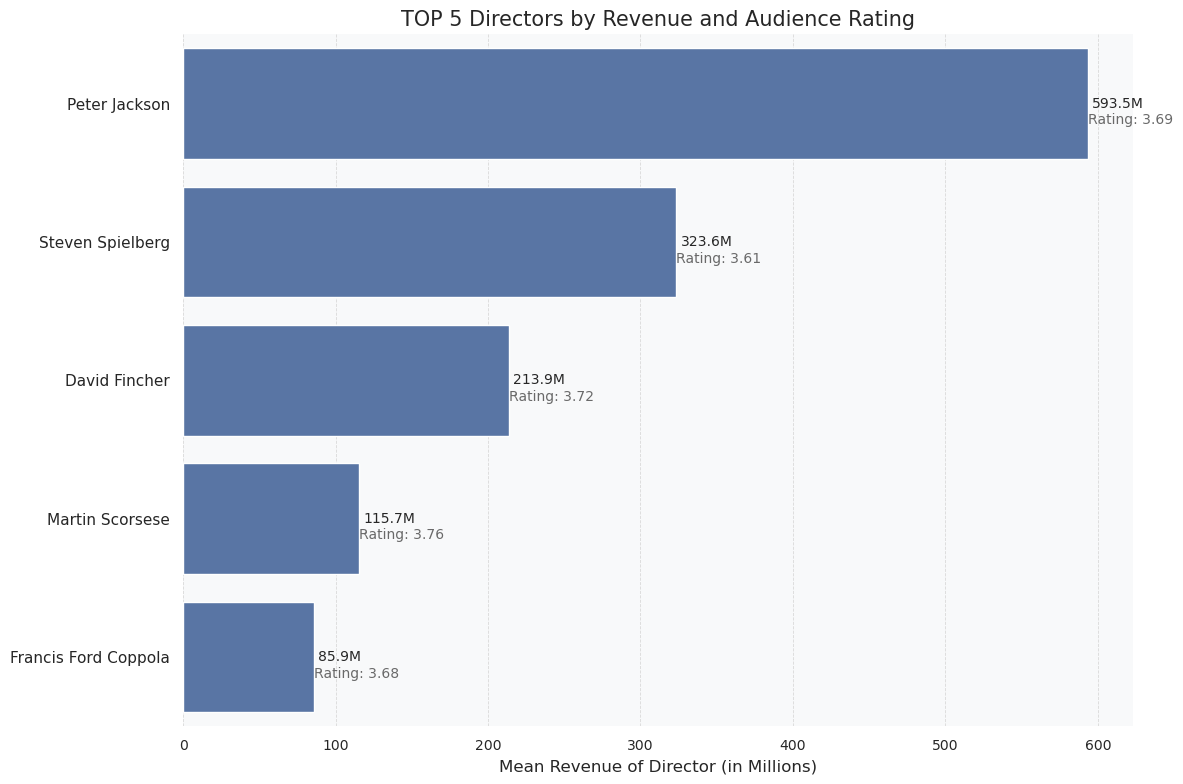

In [17]:
# Plotting a Bar Chart of TOP 5 Directors with Revenue and Rating labels
plt.figure(figsize =(12,8))
ax = sns.barplot(y=filtered_dir_df.index,x='mean_revenue_mn',data=filtered_dir_df)

# Labels and title
ax.set_ylabel(None)
ax.set_xlabel('Mean Revenue of Director (in Millions)')
ax.set_title('TOP 5 Directors by Revenue and Audience Rating')

# Revenue labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1fM', padding=3,fontsize =10)
    
# Add weighted rating annotations
for i, value in enumerate(filtered_dir_df['mean_revenue_mn']):
    
    rating = filtered_dir_df['avg_weighted_rating'].iloc[i]
    
    ax.text(
        value,              # position slightly after revenue label
        i+0.12,
        f'Rating: {rating:.2f}',
        va='center',
        fontsize=10,
        color='dimgray'
    )
# Remove borders for cleaner plot
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Top 5 Production Companies by Revenue

This analysis identifies the top-performing production studios based on the average box office revenue generated across their movies.

To improve the statistical reliability of the results, only movies with a minimum review count of 500 were included in the analysis. Additionally, only studios with at least 25 movies in the filtered dataset were considered for comparison.

In [18]:
# Creating studio level statistics and Ranking the studios by average revenue generated
studio_df = filtered_df.groupby('primary_company').agg(movie_count = ('movieId','count'),
                                    mean_revenue = ('revenue','mean'),
                                    avg_weighted_rating =('weighted_rating','mean')).\
                                sort_values(by=['mean_revenue','avg_weighted_rating'],ascending =[False,False])

In [19]:
# Filtering studios with more than 25 movies 
filtered_studio_df = studio_df[studio_df['movie_count'] >=25].head()
filtered_studio_df['mean_revenue_mn'] = (filtered_studio_df['mean_revenue']/1000000).round(2)
filtered_studio_df['avg_weighted_rating'] = filtered_studio_df['avg_weighted_rating'].round(2)
filtered_studio_df

,movie_count,mean_revenue,avg_weighted_rating,mean_revenue_mn
primary_company,,,,
Walt Disney Pictures,99,3.564108e+08,3.40,356.41
Summit Entertainment,30,2.143697e+08,3.40,214.37
DreamWorks SKG,54,2.022951e+08,3.42,202.30
Village Roadshow Pictures,63,1.883640e+08,3.30,188.36
Columbia Pictures,168,1.623357e+08,3.36,162.34


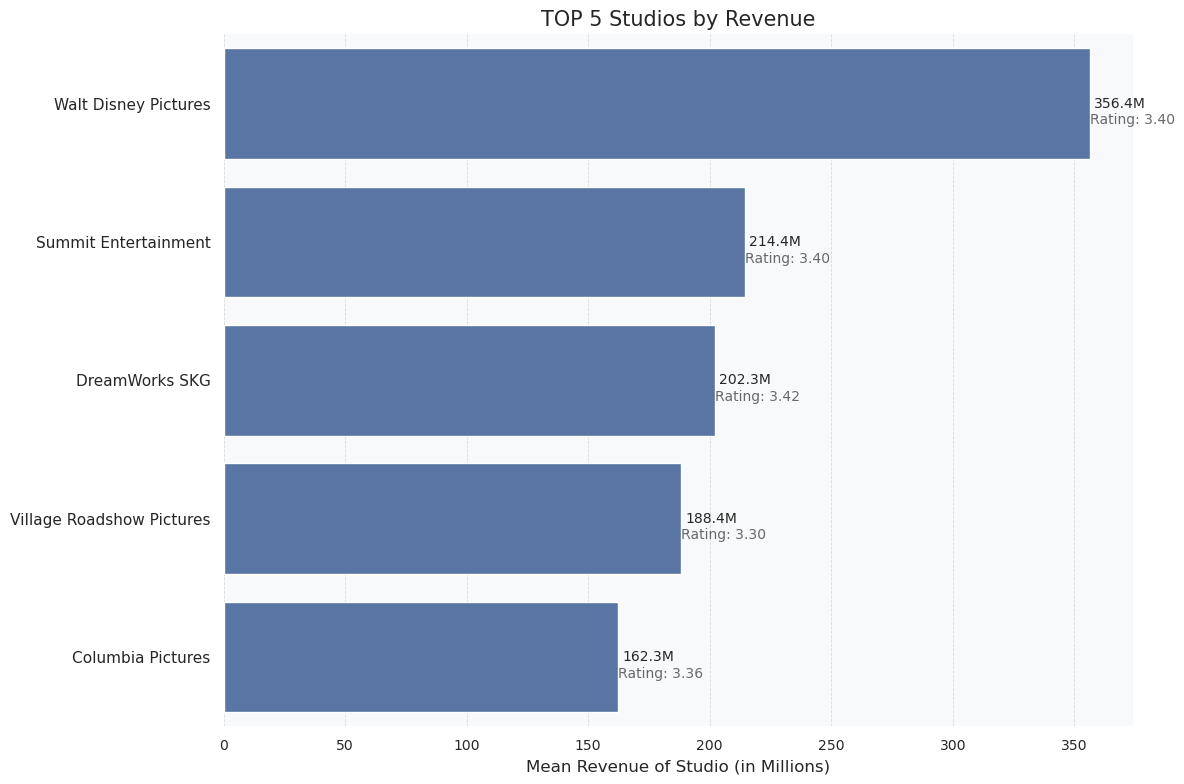

In [20]:
# Plotting a Bar Chart to visualize the TOP 5 studios
plt.figure(figsize =(12,8))
ax = sns.barplot(y=filtered_studio_df.index,x='mean_revenue_mn',data=filtered_studio_df)

# Labels and title
ax.set_ylabel(None)
ax.set_xlabel('Mean Revenue of Studio (in Millions)')
ax.set_title('TOP 5 Studios by Revenue')

# Revenue labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1fM', padding=3,fontsize =10)
    
# Add weighted rating annotations
for i, value in enumerate(filtered_studio_df['mean_revenue_mn']):
    
    rating = filtered_studio_df['avg_weighted_rating'].iloc[i]
    
    ax.text(
        value,              # position slightly after revenue label
        i+0.12,
        f'Rating: {rating:.2f}',
        va='center',
        fontsize=10,
        color='dimgray'
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Key Insights from Director and Studio Analysis

- Highly acclaimed directors such as Peter Jackson, Steven Spielberg, and Martin Scorsese tend to achieve both strong audience reception and high average box office revenue.

- Major production studios such as Walt Disney Pictures and DreamWorks SKG consistently generate high average revenues, highlighting the commercial strength of established production houses.

- The relatively small variation in audience ratings across top studios suggests that higher commercial success does not necessarily imply substantially higher audience reception.

### Audience Ratings Across Budget Tiers

This analysis examines how weighted audience ratings vary across different movie budget categories to explore whether higher-budget films receive stronger audience reception.

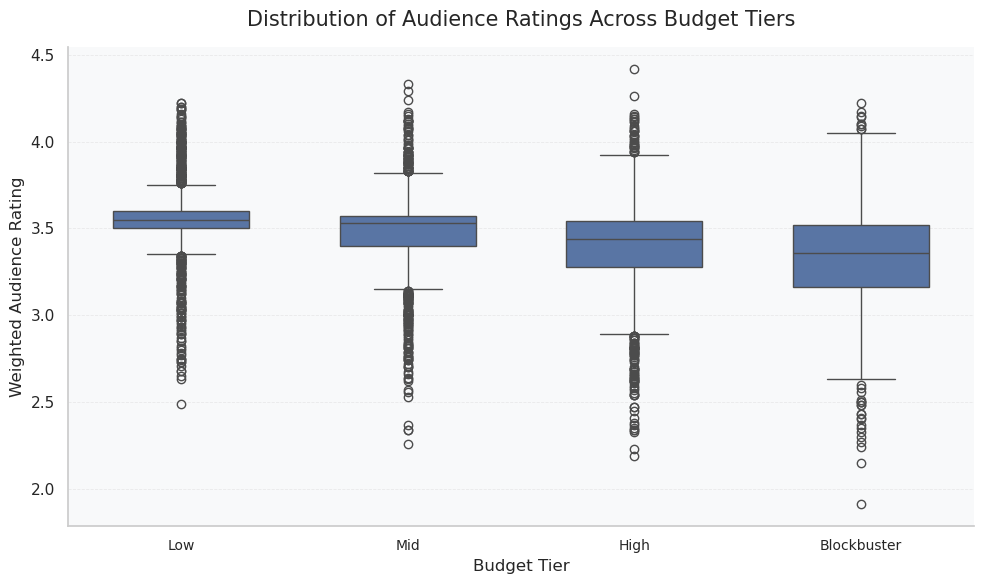

In [21]:
# Define correct budget tier order
budget_order = ['Low', 'Mid', 'High', 'Blockbuster']
plt.figure(figsize=(10,6))

# Create box plot of ratings by budget
ax = sns.boxplot(
    x='budget_tier',
    y='weighted_rating',
    data=financial_df,
    order=budget_order,
    width=0.6
)

# Labels and title
ax.set_xlabel('Budget Tier')
ax.set_ylabel('Weighted Audience Rating')
ax.set_title('Distribution of Audience Ratings Across Budget Tiers', pad=15)

# Improve readability
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()

### Key Insights

Movies in the Low and Mid budget tiers show slightly higher median audience ratings compared to High and Blockbuster films, suggesting that larger production budgets do not necessarily guarantee better audience reception.

### Genre Efficiency: Which Genres Deliver the Best ROI?
This section shifts focus from raw revenue to median Return on Investment (ROI) across genres, revealing which genres consistently generate the most financial value relative to their production cost. 

In [22]:
genre_roi_df = financial_df.groupby('primary_genre').agg(movie_count =('movieId','count'),
                                                         median_roi = ('roi_capped','median'))\
                                                    .sort_values(by= 'median_roi',ascending =False)
genre_roi_df_filtered = genre_roi_df[genre_roi_df['movie_count'] >= 25]

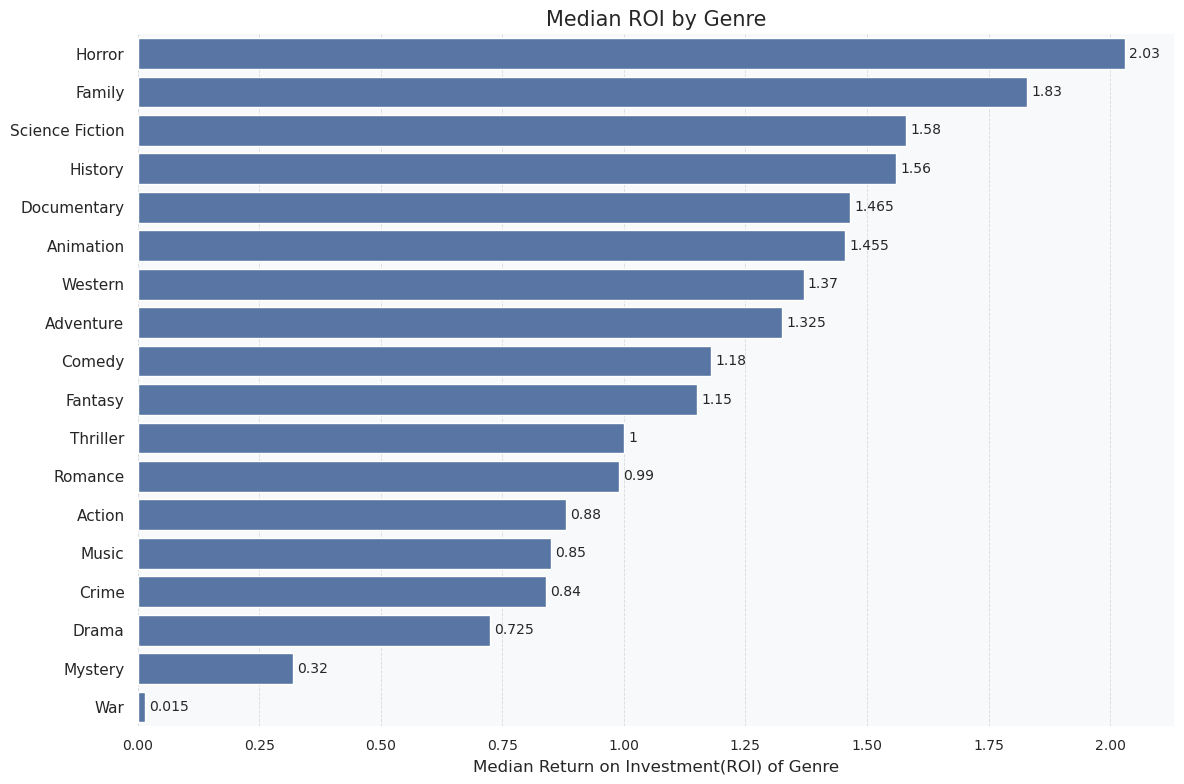

In [23]:
#Plotting a Bar Chart of Median ROI by genres 
plt.figure(figsize =(12,8))
ax = sns.barplot(y=genre_roi_df_filtered.index,x='median_roi',data=genre_roi_df_filtered)
ax.set_xlabel('Median Return on Investment(ROI) of Genre')
ax.set_ylabel(None)
ax.set_title('Median ROI by Genre')
for container in ax.containers:
    ax.bar_label(container, padding=3,fontsize =10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Key Insights
Genre is a meaningful financial lever. Leaner genres — Horror (2.03), Documentary (1.465), History (1.56) — consistently outperform big-budget counterparts on ROI, making them the stronger choice for capital-efficient filmmaking. 

### Variable Correlation Analysis
This section presents a Pearson correlation matrix across six variables central to the project's research question — **budget** , **revenue**, **popularity**, **weighted rating**, **review count**, and **runtime** — to quantify the direction and strength of pairwise relationships

In [24]:
# Creating dataframe with variables central to project research question
corr_df = financial_df[['budget','revenue','runtime','popularity','weighted_rating','review_count']]

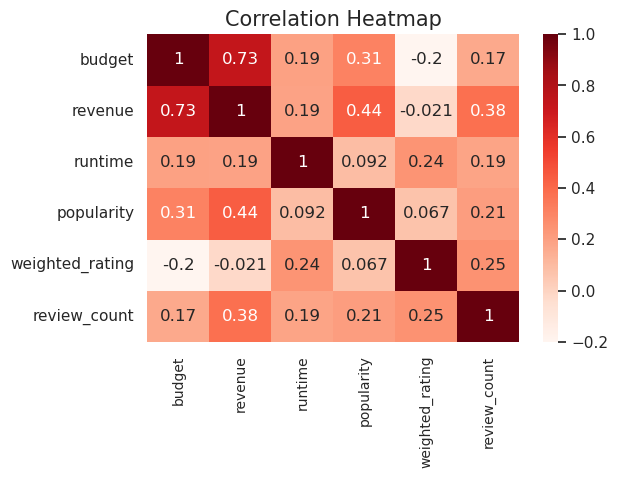

In [25]:
# Plotting a Heatmap of variables using Pearson method for correlation
plt.figure(figsize=(6,4))
sns.heatmap(corr_df.corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation Heatmap',
          fontsize=15)
plt.show()

### Key Insights
- Budget and revenue share the strongest relationship (r = 0.73)
- Popularity is a meaningful revenue predictor (r = 0.44)
- Weighted rating is largely decoupled from financial variables

## Hypothesis Testing

## Financial Success tests

### Budget tier vs Revenue
To statistically evaluate whether movie budget levels influence box office performance, a one-way ANOVA test was conducted between budget tiers and movie revenue. The null and alternate hypothesis are as below-

**Null Hypothesis (H₀):** 
There is no significant difference in mean revenue across different budget tiers. 

**Alternative Hypothesis (H₁):**
At least one budget tier has a significantly different mean revenue. 



In [26]:
# Defining budget tier order
budget_tiers =['Low','Mid','High','Blockbuster']

# Creating list of revenue arrays for each budget tier
revenue_groups = [financial_df.loc[financial_df['budget_tier'] == tier,'revenue']
                  for tier in budget_tiers]
# Running One-Way ANOVA test
f_stat, p_value = stats.f_oneway(*revenue_groups)

# Print results
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value: {p_value:.6f}')

F-statistic: 727.1824
P-value: 0.000000


### Insight from ANOVA test
The ANOVA results indicate a statistically significant difference in mean box office revenue across the different budget tiers.

### Perform an ANOVA post hoc test

Since the one-way ANOVA test indicated statistically significant differences in mean revenue across budget tiers, a Tukey HSD post-hoc test was conducted to identify which specific budget tier pairs differed significantly from one another.

In [27]:
# Conducting ANOVA post-hoc analysis using Tukey-hsd method
tukey_oneway = pairwise_tukeyhsd(endog = financial_df["revenue"], groups =financial_df ["budget_tier"])
tukey_oneway.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Blockbuster,High,-175478334.583,0.0,-189524081.0928,-161432588.0732,True
Blockbuster,Low,-232599708.0439,0.0,-246766166.3995,-218433249.6883,True
Blockbuster,Mid,-210583948.8107,0.0,-224658558.7672,-196509338.8543,True
High,Low,-57121373.4609,0.0,-70908510.2701,-43334236.6517,True
High,Mid,-35105614.2277,0.0,-48798358.4553,-21412870.0001,True
Low,Mid,22015759.2332,0.0003,8199218.7181,35832299.7483,True


### Insight from post-hoc ANOVA analysis
The results of the Tukey HSD test showed that all pairwise comparisons between budget tiers were statistically significant at the 5% significance level (p < 0.05).

### Release Season vs Revenue
A one-way ANOVA test was conducted to compare the average revenues of movies released during Summer, Year-End, and Other release periods and confirm if there is statistically significant different in mean revenues between different seasons.The null and alternate hypothesis are as below- 

**Null Hypothesis (H₀):**
  There is no significant difference in mean box office revenue across the different release     seasons. 

**Alternative Hypothesis (H₁):**
   At least one release season has a significantly different mean box office revenue.

In [28]:
# Defining release seasons list
release_seasons =['Summer','Year-End','Other']

# Creating list of revenue arrays for each release season
revenue_groups_1 = [financial_df.loc[financial_df['release_season'] == season,'revenue']
                  for season in release_seasons]
# Running One-Way ANOVA test
f_stat_1, p_value_1 = stats.f_oneway(*revenue_groups_1)

# Print results
print(f'F-statistic: {f_stat_1:.4f}')
print(f'P-value: {p_value_1:.6f}')

F-statistic: 37.6257
P-value: 0.000000


### Insight from ANOVA test
The ANOVA results indicate a statistically significant difference in mean box office revenue across the different release seasons.

### Perform an ANOVA post hoc test
Since the one-way ANOVA test indicated statistically significant differences in mean revenue across release seasons, a Tukey HSD post-hoc test was conducted to identify which specific release season pairs differed significantly from one another.

In [29]:
# Conducting ANOVA post-hoc analysis using Tukey-hsd method
tukey_oneway_1 = pairwise_tukeyhsd(endog = financial_df["revenue"], groups =financial_df ["release_season"])
tukey_oneway_1.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Other,Summer,35447519.4383,0.0,22806543.1096,48088495.7669,True
Other,Year-End,44119912.236,0.0,29840636.5766,58399187.8954,True
Summer,Year-End,8672392.7978,0.4242,-7601756.0947,24946541.6902,False


### Insights from post-hoc ANOVA analysis
These findings suggest that movies released during peak theatrical windows such as Summer and Year-End tend to achieve higher box office revenues, while the financial performance between these two peak seasons remains statistically similar. 

## Audience Reception tests

### Studio Tier vs Ratings
To investigate the relationship between production studio and weighted ratings, an exploratory analysis was first conducted to compare the average weighted audience ratings of movies produced by Major Studios and Independent Studios. Subsequently, **Welch’s independent two-sample t-test** was performed to statistically evaluate whether the observed difference in ratings was significant. 

The Null and Alternate Hypothesis are as below-

**Null Hypothesis(H₀):** There is no statistically significant difference in the mean weighted audience ratings between movies produced by Major Studios and Independent Studios. 

**Alternate Hypothesis(H₁):** There is a statistically significant difference in the mean weighted audience ratings between movies produced by Major Studios and Independent Studios 


In [30]:
# Exploratory Analysis to check difference in weighted rating means between studio tiers
filtered_df.groupby('studio_label')['weighted_rating'].mean().round(2)

studio_label
Independent     3.49
Major Studio    3.39
Name: weighted_rating, dtype: float64

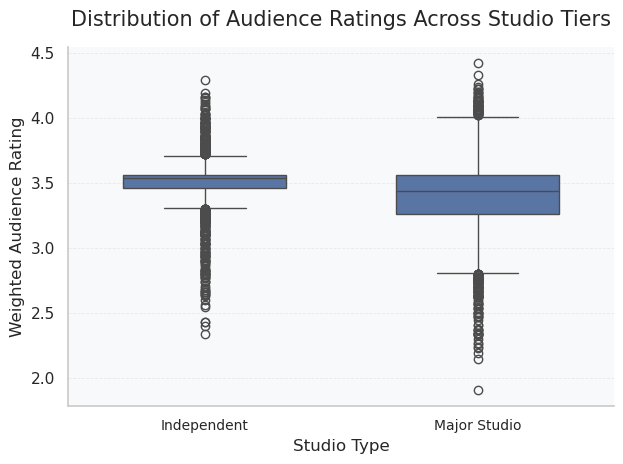

In [31]:
# Boxplot of weighted rating by studio label to confirm if rating distributions differ

ax = sns.boxplot(
    x='studio_label',
    y='weighted_rating',
    data=financial_df,
    width=0.6
)

# Labels and title
ax.set_xlabel('Studio Type')
ax.set_ylabel('Weighted Audience Rating')
ax.set_title('Distribution of Audience Ratings Across Studio Tiers', pad=15)

# Improve readability
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()


In [32]:
# Independent Two Sample t-tests to confirm statistical significance
major_studio_ratings = filtered_df[filtered_df['studio_tier'] == 1]['weighted_rating']
ind_studio_ratings = filtered_df[filtered_df['studio_tier'] == 0]['weighted_rating']
t_stat_2, p_value_2 = stats.ttest_ind(major_studio_ratings,ind_studio_ratings,equal_var=False)
# Print results
print(f'T-statistic: {t_stat_2:.4f}')
print(f'P-value: {p_value_2:.6f}')

T-statistic: -7.0475
P-value: 0.000000


### Key Insights
The results of Welch’s t-test indicate that the difference in weighted audience ratings between Major and Independent Studios is **statistically significant at the 5% significance level**. Since the p-value is substantially lower than 0.05, the null hypothesis of equal mean ratings between the two studio categories is rejected.

###  Genre vs Weighted Ratings
To examine whether audience ratings differ significantly across movie genres, a one-way ANOVA test was conducted using weighted audience ratings

In [33]:
# Checking count of movies in each genre to decide on a minimum threshold
filtered_df.groupby('primary_genre')['movieId'].count()

primary_genre
Action             596
Adventure          306
Animation           97
Comedy             625
Crime              170
Documentary         21
Drama              718
Family              35
Fantasy            105
History             16
Horror             202
Music               16
Mystery             41
Romance             62
Science Fiction     87
Thriller           113
War                 15
Western             19
Name: movieId, dtype: int64

In [86]:
# Creating genre-level dataframe with movie count and average weighted rating

genre_rating_df = filtered_df.groupby('primary_genre').agg(movie_count =('movieId','count'),
                                                         avg_weighted_rating = ('weighted_rating','mean'))\
                                                    .sort_values(by= 'avg_weighted_rating',ascending =False)
# Filtering the genre dataframe to only include genres with more than 25 movies
genre_rating_filt_df = genre_rating_df[genre_rating_df['movie_count'] >= 25]
genre_rating_filt_df['avg_weighted_rating'] = genre_rating_filt_df['avg_weighted_rating'].round(2)
genre_rating_filt_df

/tmp/ipykernel_165/3895976134.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_rating_filt_df['avg_weighted_rating'] = genre_rating_filt_df['avg_weighted_rating'].round(2)


,movie_count,avg_weighted_rating
primary_genre,,
Drama,718,3.57
Crime,170,3.57
Mystery,41,3.51
Romance,62,3.46
Animation,97,3.46
Thriller,113,3.39
Adventure,306,3.38
Fantasy,105,3.37
Comedy,625,3.36


In [87]:
#Creating a list of all genres eligible for ANOVA analysis
genres_list = list(genre_rating_filt_df.index)

# Creating a separate dataframe to include only eligible genres
eligible_genre_df = filtered_df[filtered_df['primary_genre'].isin(genres_list)]


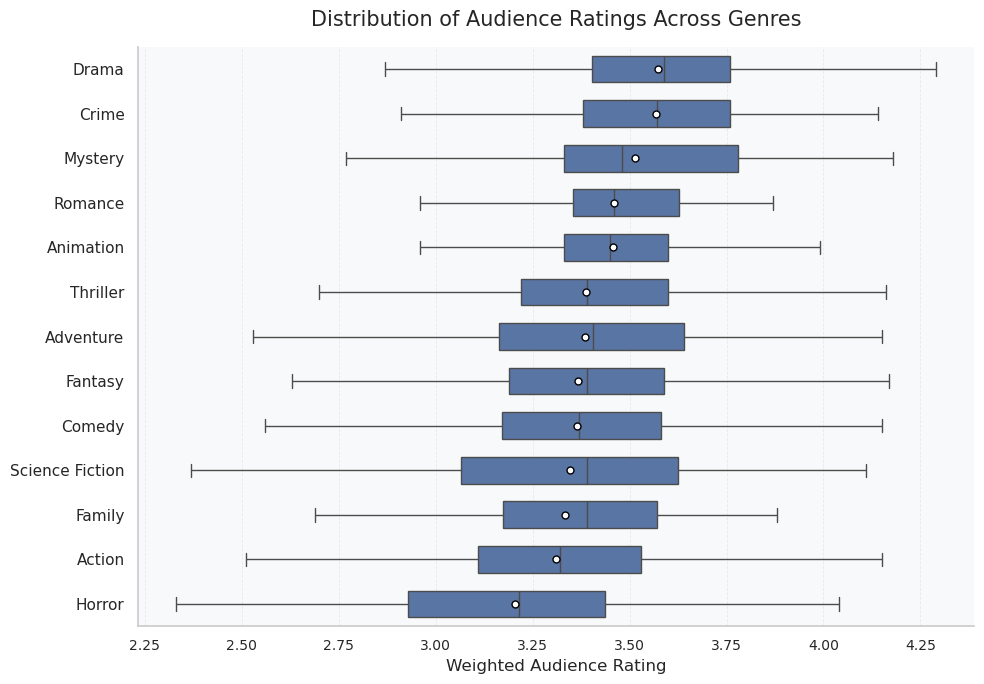

In [88]:
# Creating list of eligible genres by decreasing average weighted rating
genre_order = (
    eligible_genre_df.groupby('primary_genre')['weighted_rating']
    .mean()
    .sort_values(ascending=False)
    .index
)

# Boxplot of weighted rating by genre to confirm if rating distributions differ

plt.figure(figsize =(10,7))

ax = sns.boxplot(
    x='weighted_rating',
    y='primary_genre',
    data=eligible_genre_df,
    showfliers =False,
    order =genre_order,
    showmeans =True,
    meanprops={
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": 5},
    width=0.6
)

# Labels and title
ax.set_xlabel('Weighted Audience Rating')
ax.set_ylabel(None)
ax.set_title('Distribution of Audience Ratings Across Genres', pad=15)

# Improve readability
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()

### Insight from Boxplots
The boxplots visually indicate that higher-rated genres such as Drama and Crime generally have rating distributions centered at higher values, whereas Horror displays a comparatively lower median and mean rating distribution

### Perform a one-way ANOVA test
**Null Hypothesis (H₀)**: 
  There is no significant difference in mean weighted rating  across movie genres. 

**Alternative Hypothesis (H₁)**: 
   At least one genre has a significantly different mean weighted rating.

In [90]:
# Creating list of revenue arrays for each release season
rating_groups = [filtered_df.loc[filtered_df['primary_genre'] == genre,'weighted_rating']
                  for genre in genres_list]
# Running One-Way ANOVA test
f_stat_2, p_value_2 = stats.f_oneway(*rating_groups)

# Print results
print(f'F-statistic: {f_stat_2:.4f}')
print(f'P-value: {p_value_2:.6f}')
print(len(rating_groups))

F-statistic: 33.4709
P-value: 0.000000
13


### Insights from ANOVA test
The ANOVA results indicate a **statistically significant difference** in average weighted audience ratings across movie genres. Since the p-value is substantially lower than the 5% significance level, the null hypothesis is rejected

### Perform a ANOVA post-hoctest
Following the significant ANOVA results, a **Tukey HSD post-hoc** test was conducted to identify which genre pairs differed significantly in average weighted audience ratings

In [53]:
# Conducting ANOVA post-hoc analysis using Tukey-hsd method
tukey_oneway_2 = pairwise_tukeyhsd(endog = eligible_genre_df["weighted_rating"], groups = eligible_genre_df['primary_genre'])
tukey_oneway_2.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Action,Adventure,0.0742,0.0531,-0.0004,0.1489,False
Action,Animation,0.1462,0.0022,0.03,0.2624,True
Action,Comedy,0.0538,0.1455,-0.0069,0.1146,False
Action,Crime,0.2582,0.0,0.1659,0.3505,True
Action,Drama,0.2638,0.0,0.205,0.3226,True
Action,Family,0.0235,1.0,-0.1611,0.2082,False
Action,Fantasy,0.0575,0.8957,-0.0548,0.1699,False
Action,Horror,-0.1059,0.0034,-0.1923,-0.0195,True
Action,Mystery,0.203,0.0058,0.0316,0.3744,True
Action,Romance,0.1493,0.0279,0.0077,0.291,True


### Insights from post-hoc analysis
- The post-hoc analysis revealed that genres such as **Drama** and **Crime** generally received significantly higher audience ratings compared to genres like **Horror**, **Fantasy**, **Science Fiction**, and **Thriller**. In particular, **Horror** movies consistently showed lower average audience ratings relative to several other genres. 

- However, many genre pairs did not exhibit statistically significant differences, suggesting that audience reception overlaps considerably across several movie genres

## Regression Analysis

In this section regression models are designed with revenue as the dependent variable and budget,studio_tier and genre as the independent variables. The objective is to analyze how much of variation in revenue is explained by various factors.This will help answer the business question central to the project.

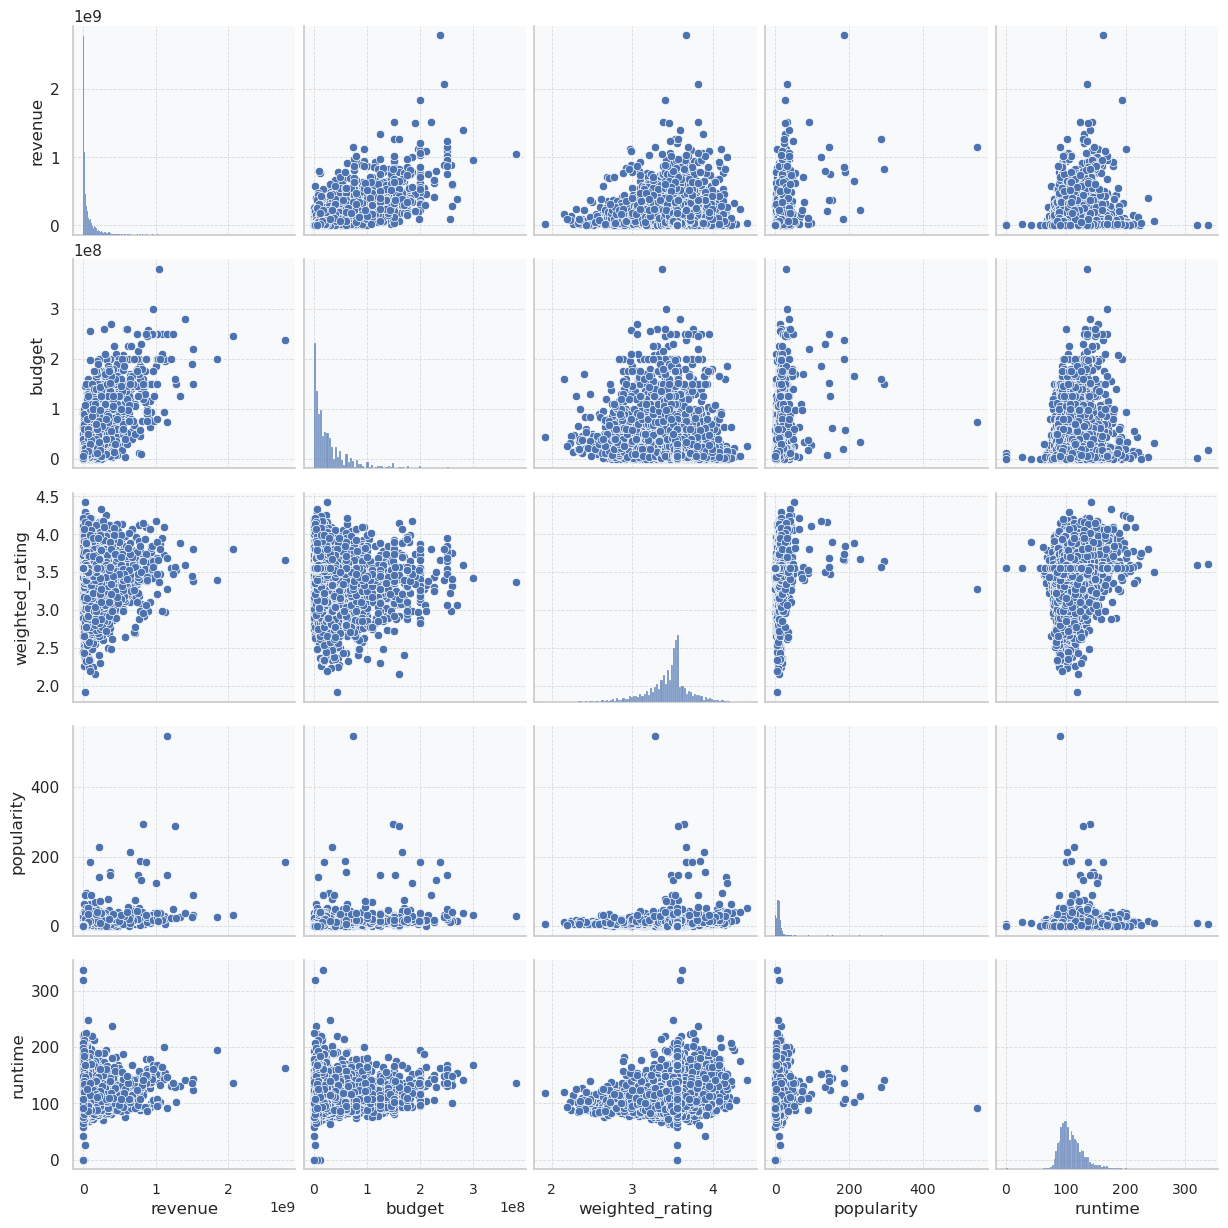

In [60]:
# Checking which variables have a linear relationship with the revenue
sns.pairplot(financial_df[['revenue','budget','weighted_rating','popularity','runtime']])

### Insight from the Pairplot

It is clear from the above pairplot that budget has the most linear relationship with the revenue. Besides budget weighted rating also seems to have a linar relation with revenue.

## Simple Linear Regression

This section builds a linear regression model with revenue as the dependent variable and budget as the independent variable.

In [61]:
# Defining the OLS formula.
ols_formula = 'revenue ~ budget'

# Creating an OLS model.
OLS = ols(formula = ols_formula, data = financial_df)

# Fitting the model.
model = OLS.fit()

# Saving the results summary.
model_results = model.summary()

# Display the model results.
model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     6121.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        11:37:49   Log-Likelihood:            -1.0713e+05
No. Observations:                5365   AIC:                         2.143e+05
Df Residuals:                    5363   BIC:                         2.143e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -3.65e+06   1.96e+06     -1.858      0.063    -7.5e+06    2.01e+05
budget         3.0213      0.039     78.240      0.000       2.946       3.097
==============================================================================
Omnibus:                     4620.031   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           354447.865
Skew:                           3.704   Prob(JB):                         0.00
Kurtosis:                      42.124   Cond. No.                     6.44e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.44e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Insight from above Regression Model
- The model shows that around 53% of variation in revenue is explained by budget alone which suggests that budget is a strong predictor of revenue.
- However, since the model used variables revenue and budget which are extremely right-skewed the model violates the OLS model assumptions of normally distributed residuals and homoscedasticity (constant variance). This can be inferred from the very high values for Skew(3.704) and Kurtosis (42.124).
- To improve the model's compliance to OLS assumptions another model is built suing the log transformed variables for both revenue and budget to reduce skewness in distributions.


In [63]:
ols_formula_1 = 'log_revenue ~ log_budget'

# Creating an OLS model.
OLS_1 = ols(formula = ols_formula_1, data = financial_df)

# Fitting the model.
model_1 = OLS_1.fit()

# Saving the results summary.
model_results_1 = model_1.summary()

# Display the model results.
model_results_1

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_revenue   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                     5221.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        11:46:00   Log-Likelihood:                -10921.
No. Observations:                5365   AIC:                         2.185e+04
Df Residuals:                    5363   BIC:                         2.186e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3997      0.200     11.986      0.000       2.007       2.792
log_budget     0.8817      0.012     72.258      0.000       0.858       0.906
==============================================================================
Omnibus:                     1928.032   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            23661.439
Skew:                          -1.363   Prob(JB):                         0.00
Kurtosis:                      12.920   Cond. No.                         130.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Insights from Reression Model with log transformed variables

The log transfomed variables greatly improved the model performance with respect to the OLS model assumptions. The comparison of the two models is tabulated below-

                        | Metric        | Raw Model | Log Model | Improvement         |
                        | ------------- | --------- | --------- | ------------------- |
                        | Skewness      | 3.704     | -1.363    | Much better         |
                        | Kurtosis      | 42.124    | 12.920    | Huge improvement    |
                        | Jarque-Bera   | 354447    | 23661     | Massive reduction   |
                        | Condition No. | 6.44e+07  | 130       | Dramatically better |

This suggests that the log transformation substantially reduced:

- Extreme skewness
- Heavy tails
- Influence of blockbuster outliers
- Numerical instability.

To further confirm the improvement the histogram of residuals of both the models are plotted below.


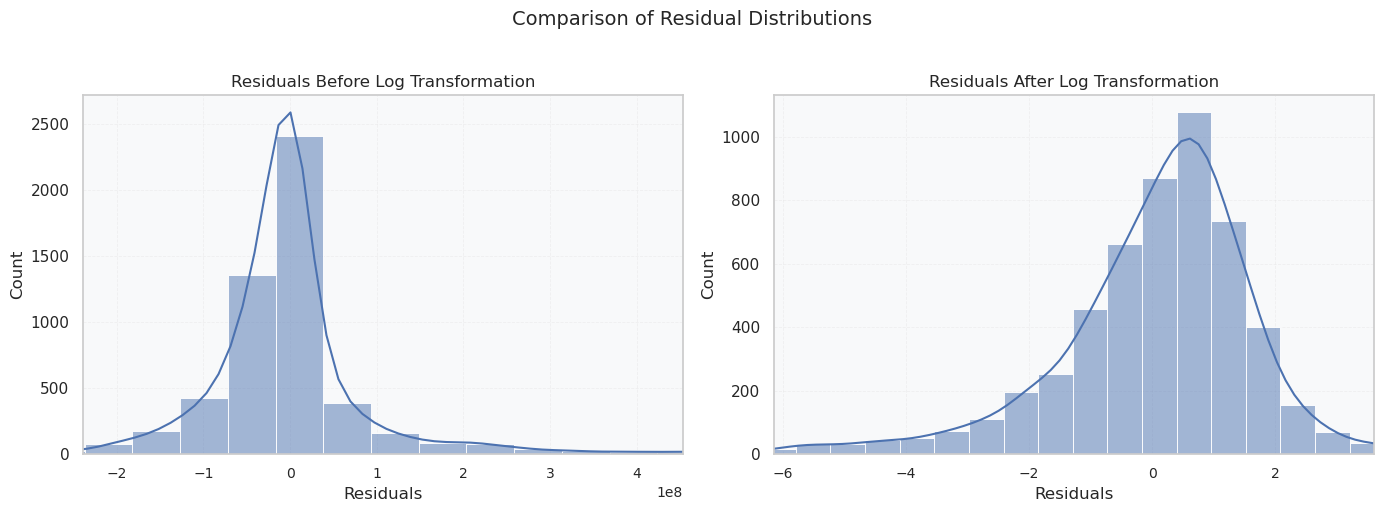

In [68]:
# Residuals
residuals_raw = model.resid
residuals_log = model_1.resid

# Clipping extreme outliers ONLY for visualization
raw_limits = np.percentile(residuals_raw, [1, 99])
log_limits = np.percentile(residuals_log, [1, 99])

# Creating figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram BEFORE transformation
sns.histplot(
    residuals_raw,
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_xlim(raw_limits)
axes[0].set_title(
    "Residuals Before Log Transformation",
    fontsize=12
)
axes[0].set_xlabel("Residuals")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

# Histogram AFTER transformation
sns.histplot(
    residuals_log,
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_xlim(log_limits)
axes[1].set_title(
    "Residuals After Log Transformation",
    fontsize=12
)
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

# Overall title
fig.suptitle(
    "Comparison of Residual Distributions",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

### Insights from Residual Histograms

The residual distribution after logarithmic transformation appears substantially more symmetric and approximately normal compared to the original model, indicating improved compliance with OLS regression assumptions.


### Model Diagnostics

This section checks whether the model violates the four assumptions of Simple Linear Regression given below -

* Linearity
* Independent Observations
* Normality
* Homoscedasticity

### Linearity Assumption

Text(0.5, 1.0, 'Log Revenue Vs Log Budget')

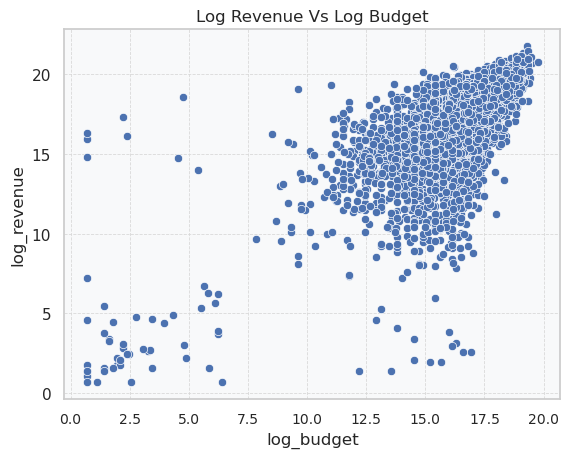

In [83]:
# Create a scatterplot between log revenue and log budget
ax= sns.scatterplot(x = financial_df['log_budget'], y = financial_df['log_revenue'])
ax.set_title('Log Revenue Vs Log Budget',size=12)

In [76]:
# Check Pearson correlation between these variables
financial_df['log_budget'].corr(financial_df['log_revenue'])

0.7023536842632377

#### Comment on Linearity Assumption Compliance

- There is a clear linear relationship between log_budget and log_revenue as seen from scatterplot. 
- The pearson correlation coefficeint fo 0.70 further confirms the linarity.
- Thus, it can be said that linearity assumption is met.

### Normality Assumption
The normality assumption states that the errors(residuals) are normally distributed.

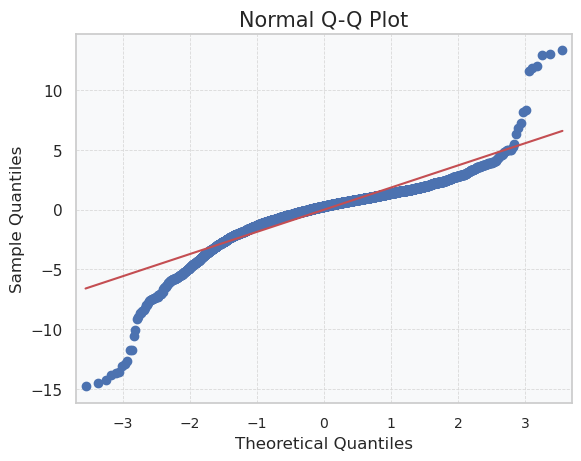

In [78]:
# Plotting the Q-Q plot of Residuals for log transformed model
fig = sm.qqplot(residuals_1, line='s')
ax = fig.axes[0]
ax.set_title('Normal Q-Q Plot')
plt.show()

#### Comment on Normality Assumption Compliance
- The Q-Q plot showed that most residuals aligned reasonably well with the reference line in the central region, indicating approximate normality for the majority of observations.
- However, noticeable deviations were still present in the tails, suggesting the presence of some extreme observations and remaining non-normality.
- Such tail deviations are common in movie revenue datasets due to blockbuster outliers and the highly variable nature of box office performance.
- Thus thus the model can be said to comply to the Normality Assumption.

### Homoscedasticity Assumption

The **homoscedasticity (constant variance) assumption** is that the residuals have a constant variance for all values of `X`.

This section checks that this assumption is not violated by creating a scatterplot with the fitted values and residuals. Add a line at $y = 0$ to visualize the variance of residuals above and below $y = 0$.

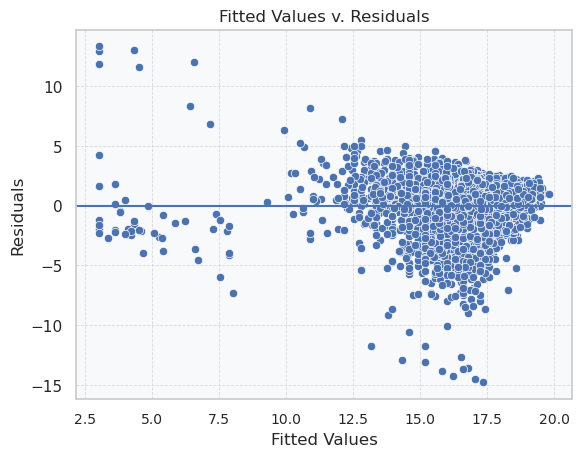

In [81]:
# Create a scatterplot with the fitted values from the model and the residuals.

fig = sns.scatterplot(x = model_1.fittedvalues, y = model_1.resid)

# Set the x-axis label.
fig.set_xlabel("Fitted Values")

# Set the y-axis label.
fig.set_ylabel("Residuals")

# Set the title.
fig.set_title("Fitted Values v. Residuals", size=12)

# Add a line at y = 0 to visualize the variance of residuals above and below 0.

fig.axhline(0)

# Show the plot.
plt.show()

### Independent Observations Assumption
The **independent observation assumption** states that each observation in the dataset is independent. As movies' revenue are independent from one another, the independence assumption is not violated.

## Multiple Linear Regression Model
To further investigate the factors influencing movie financial performance, a Multiple Linear Regression model was developed using log-transformed revenue as the dependent variable and the following predictors: 

- Log-transformed production budget (log_budget)  

- Primary movie genre (primary_genre)  

- Studio tier (studio_tier)

Genres with fewer than 100 movies were excluded from the analysis to improve statistical reliability and reduce instability caused by sparsely represented categories. Drama was selected as the baseline reference genre for coefficient interpretation. 

In [94]:
# Creating separate dataframe for regression including genres with more than 100 movies
genre_counts = financial_df['primary_genre'].value_counts()
reg_eligible_genres = genre_counts[genre_counts >= 100].index
regression_df = financial_df[financial_df['primary_genre'].isin(reg_eligible_genres)]

(5059, 23)

In [96]:
# Multiple Regression OLS formula 
ols_formula_2 = 'log_revenue ~ log_budget + C(primary_genre, Treatment(reference="Drama")) + C(studio_tier)'

# Creating an OLS model.
OLS_2 = ols(formula = ols_formula_2, data = regression_df)

# Fitting the model.
model_2 = OLS_2.fit()

# Saving the results summary.
model_results_2 = model_2.summary()

# Display the model results.
model_results_2

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_revenue   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     428.2
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        15:16:29   Log-Likelihood:                -9671.0
No. Observations:                4908   AIC:                         1.937e+04
Df Residuals:                    4895   BIC:                         1.945e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=====================================================================================================================================
                                                                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                             2.7339      0.216     12.651      0.000       2.310       3.158
C(primary_genre, Treatment(reference="Drama"))[T.Action]              0.1928      0.076      2.527      0.012       0.043       0.342
C(primary_genre, Treatment(reference="Drama"))[T.Adventure]           0.5058      0.101      5.033      0.000       0.309       0.703
C(primary_genre, Treatment(reference="Drama"))[T.Animation]           0.6401      0.154      4.149      0.000       0.338       0.943
C(primary_genre, Treatment(reference="Drama"))[T.Comedy]              0.2719      0.073      3.711      0.000       0.128       0.416
C(primary_genre, Treatment(reference="Drama"))[T.Crime]              -0.1342      0.118     -1.139      0.255      -0.365       0.097
C(primary_genre, Treatment(reference="Drama"))[T.Fantasy]             0.1900      0.157      1.211      0.226      -0.118       0.498
C(primary_genre, Treatment(reference="Drama"))[T.Horror]              0.5818      0.109      5.335      0.000       0.368       0.796
C(primary_genre, Treatment(reference="Drama"))[T.Romance]             0.0470      0.168      0.280      0.780      -0.282       0.376
C(primary_genre, Treatment(reference="Drama"))[T.Science Fiction]     0.4502      0.178      2.532      0.011       0.102       0.799
C(primary_genre, Treatment(reference="Drama"))[T.Thriller]           -0.0551      0.134     -0.411      0.681      -0.318       0.208
C(studio_tier)[T.1.0]                                                 0.7755      0.055     14.036      0.000       0.667       0.884
log_budget                                                            0.8198      0.014     60.246      0.000       0.793       0.847
==============================================================================
Omnibus:                     1863.503   Durbin-Watson:                   1.886
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21622.660
Skew:                          -1.479   Prob(JB):                         0.00
Kurtosis:                      12.848   Cond. No.                         146.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Insights from Multiple Regression Model

- Production budget remained the **strongest predictor of movie revenue** even after controlling for genre and studio tier.  

- The coefficient for log_budget **(0.820)** indicates that a **1% increase in production budget is associated with an approximate 0.82% increase in movie revenue**, holding genre and studio tier constant. 

- The coefficient for studio tier **(0.776)** implies that holding budget and genre constant, movies produced by major studios are associated with **approximately 117% higher expected box office revenue compared to movies produced by independent studios.** 

- The coefficient for Adventure **(0.506)** suggests that holding budget and studio tier constant, Adventure movies are associated with **approximately 66% higher expected box office revenue compared to Drama movies.** 

- Most predictor variables were **statistically significant (p < 0.05)**, suggesting that budget, studio tier, and several movie genres have **meaningful associations with box office revenue**. 

### No Multi-collinearity Assumption

The **no multicollinearity assumption** states that no two independent variables ($X_i$ and $X_j$) can be highly correlated with each other. 

This analysis checks if the multiple regression model complies with this assumption by 

 Using the **variance inflation factor** method to detect multicollinearity.

In [97]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

# Creating design matrices from the regression formula
y, X = dmatrices(
    'log_revenue ~ log_budget + C(primary_genre, Treatment(reference="Drama")) + C(studio_tier)',
    data=regression_df,
    return_type='dataframe'
)

# Creating a dataframe for VIF values
vif_df = pd.DataFrame()

# Variable names
vif_df["Variable"] = X.columns

# Calculating VIF for each predictor
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Display VIF table
vif_df

,Variable,VIF
0,Intercept,75.866116
1,"C(primary_genre, Treatment(reference=""Drama""))...",1.457069
2,"C(primary_genre, Treatment(reference=""Drama""))...",1.253385
3,"C(primary_genre, Treatment(reference=""Drama""))...",1.101298
4,"C(primary_genre, Treatment(reference=""Drama""))...",1.442763
5,"C(primary_genre, Treatment(reference=""Drama""))...",1.145272
6,"C(primary_genre, Treatment(reference=""Drama""))...",1.085865
7,"C(primary_genre, Treatment(reference=""Drama""))...",1.177246
8,"C(primary_genre, Treatment(reference=""Drama""))...",1.066890
9,"C(primary_genre, Treatment(reference=""Drama""))...",1.065497


### Insight from VIF analysis

All predictor variables showed VIF values close to 1 and well below the commonly accepted threshold of 5, indicating that **multicollinearity was not a significant concern in the regression model.**